In [16]:
# Imports 

"""
Identifying Exoplanets in Habitable Zones
-----------------------------------------
This notebook loads the NASA Exoplanet Archive Confirmed Planets CSV,
cleans the dataset, computes habitable zone boundaries using
Kopparapu et al. (2013) flux limits, classifies planets, and creates visualizations.
"""

# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Units
from astropy import units as u


In [17]:
# Load the manually downloaded CSV
# Make sure the file is in the same folder as this notebook.


df = pd.read_csv("confirmed_exoplanets.csv", comment='#')  

# Display the first few rows to verify
df.head()


,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,AU Mic b,AU Mic,1,1,4,Transit,2020,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.100,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,2024-09-28,2023-12,2024-09-28
1,AU Mic c,AU Mic,1,1,4,Transit,2021,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.100,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,2024-09-28,2023-12,2024-09-28
2,BD+05 4868 A b,BD+05 4868 A,1,2,1,Transit,2025,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.010,7.448,0.026,-0.026,9.84152,0.000476,-0.000476,2025-03-21,2025-01,2025-03-21
3,BD-14 3065 b,BD-14 3065 A,1,3,1,Transit,2024,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.013,9.932,0.026,-0.026,10.91000,0.001617,-0.001617,2024-06-25,2024-03,2024-06-25
4,DS Tuc A b,DS Tuc A,1,2,1,Transit,2019,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.030,6.676,0.034,-0.034,8.31926,0.001025,-0.001025,2019-07-03,2019-07,2019-07-11


In [18]:
# Select and clean required columns 

"""
We need:
- Stellar luminosity (L_star) in solar units
- Stellar effective temperature (Teff)
- Semi-major axis (a) in AU
"""

# Rename columns if necessary 
column_map = {
    "st_lum": "stellar_lum",   # stellar luminosity
    "st_teff": "stellar_teff", # stellar temperature
    "pl_orbsmax": "a"          # semi-major axis
}

df = df.rename(columns=column_map)

# Keep only rows with the necessary values
df = df[["pl_name", "stellar_lum", "stellar_teff", "a"]].dropna()

df.head()


,pl_name,stellar_lum,stellar_teff,a
0,AU Mic b,-1.0381,3678.0,0.0649
1,AU Mic c,-1.0381,3678.0,0.1108
2,BD+05 4868 A b,-0.7167,4596.0,0.0208
3,BD-14 3065 b,1.0600,6935.0,0.0656
6,GJ 143 b,-0.6862,4640.0,0.1915


In [20]:
# Habitable Zone calculations 

"""
Kopparapu et al. (2013) conservative limits:
---------------------------------------------
Inner edge (Runaway Greenhouse): S_inner = 1.1
Outer edge (Maximum Greenhouse): S_outer = 0.53

Habitable zone boundaries:
    r_inner = sqrt(L / S_inner)
    r_outer = sqrt(L / S_outer)

Where L is stellar luminosity in solar units.
"""
# Remove rows with impossible luminosities (0, negative, or missing)
df = df[df["stellar_lum"] > 0].copy()
df = df.dropna(subset=["stellar_lum"])

S_inner = 1.1
S_outer = 0.53

# Compute HZ boundaries
df["HZ_inner"] = np.sqrt(df["stellar_lum"] / S_inner)
df["HZ_outer"] = np.sqrt(df["stellar_lum"] / S_outer)

df.head()


,pl_name,stellar_lum,stellar_teff,a,HZ_inner,HZ_outer
3,BD-14 3065 b,1.06000,6935.0,0.06560,0.981650,1.414214
24,HD 110082 b,0.28103,6200.0,0.11300,0.505452,0.728179
27,HD 1397 b,0.65992,5521.0,0.10970,0.774550,1.115855
39,HD 202772 A b,0.97128,6272.0,0.05208,0.939671,1.353737
40,HD 20329 b,0.04922,5596.0,0.01800,0.211531,0.304742


In [21]:
# Classify Planets 

"""
Classification rules:
---------------------
Inside HZ:
    HZ_inner <= a <= HZ_outer

Borderline:
    Within ±10% of either boundary (close call)

Outside HZ:
    Everything else
"""

def classify_planet(row):
    a = row["a"]
    rin = row["HZ_inner"]
    rout = row["HZ_outer"]

    # Inside the habitable zone
    if rin <= a <= rout:
        return "Inside HZ"

    # Within 10% threshold (borderline case)
    margin_in = 0.10 * rin
    margin_out = 0.10 * rout

    if (rin - margin_in <= a <= rin + margin_in) or (rout - margin_out <= a <= rout + margin_out):
        return "Borderline"

    return "Outside HZ"

df["HZ_classification"] = df.apply(classify_planet, axis=1)

df.head()


,pl_name,stellar_lum,stellar_teff,a,HZ_inner,HZ_outer,HZ_classification
3,BD-14 3065 b,1.06000,6935.0,0.06560,0.981650,1.414214,Outside HZ
24,HD 110082 b,0.28103,6200.0,0.11300,0.505452,0.728179,Outside HZ
27,HD 1397 b,0.65992,5521.0,0.10970,0.774550,1.115855,Outside HZ
39,HD 202772 A b,0.97128,6272.0,0.05208,0.939671,1.353737,Outside HZ
40,HD 20329 b,0.04922,5596.0,0.01800,0.211531,0.304742,Outside HZ


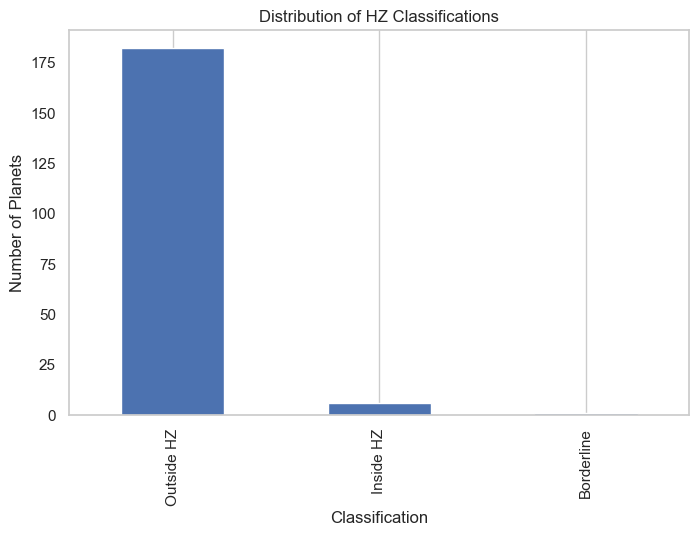

In [23]:
# VISUALIZATION — Histogram of Classifications

plt.figure(figsize=(8, 5))

df["HZ_classification"].value_counts().plot(kind="bar")

plt.xlabel("Classification")
plt.ylabel("Number of Planets")
plt.title("Distribution of HZ Classifications")
plt.grid(axis="y")
plt.show()

In [24]:
# List of Habitable Zone Candidates 

inside_hz = df[df["HZ_classification"] == "Inside HZ"]
borderline = df[df["HZ_classification"] == "Borderline"]

inside_hz[["pl_name", "a", "HZ_inner", "HZ_outer"]]

,pl_name,a,HZ_inner,HZ_outer
124,TIC 241249530 b,0.6410,0.609202,0.877647
126,TIC 279401253 b,0.3690,0.296816,0.427609
132,TIC 4672985 b,0.3300,0.321841,0.463661
357,TOI-2180 b,0.8280,0.607169,0.874718
481,TOI-3856 b,0.0325,0.028123,0.040516
553,TOI-4914 b,0.0980,0.090604,0.130529


In [ ]:
# Now that I have shown HZ classifications, I will now model the relationship between stellar luminosity and habitable zone boundaries as well as stellar temperature and habitable zone boundaries 

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


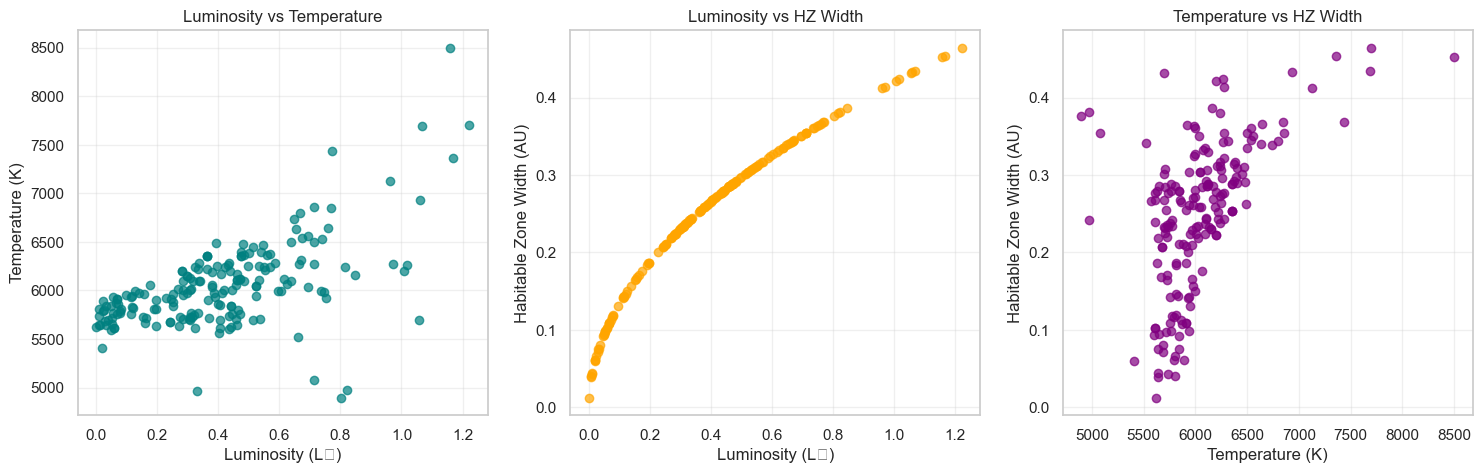

In [38]:
"""
Purpose:
    This visualizes how habitable zone width relates to stellar properties
    
    1. Luminosity vs Temperature:
       - Essentially an H-R diagram for the stars in the dataset
       - Shows the distribution of stellar types
       - Helps contextualize which stars are likely to have habitable zones
       
    2. Luminosity vs HZ Width:
       - Shows how a star's brightness affects the size of its habitable zone
       - More luminous stars tend to have wider HZs
       - Provides intuition on the amount of habitable territory around different stars

    3. Temperature vs HZ Width:
       - Illustrates how stellar temperature affects HZ width
       - Cooler stars generally have narrower HZs close in, hotter stars have wider HZs farther out
"""

# Calculate Habitable Zone width (difference between outer and inner boundaries)
df["HZ_width"] = df["HZ_outer"] - df["HZ_inner"]

# Create a figure with 3 subplots in a single row
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# -----------------------
# Subplot 1: Luminosity vs Temperature
# -----------------------
axes[0].scatter(df["stellar_lum"], df["stellar_teff"], alpha=0.7, color='teal')
axes[0].set_xlabel("Luminosity (L☉)")
axes[0].set_ylabel("Temperature (K)")
axes[0].set_title("Luminosity vs Temperature")
axes[0].grid(alpha=0.3)

# -----------------------
# Subplot 2: Luminosity vs HZ Width
# -----------------------
axes[1].scatter(df["stellar_lum"], df["HZ_width"], alpha=0.7, color='orange')
axes[1].set_xlabel("Luminosity (L☉)")
axes[1].set_ylabel("Habitable Zone Width (AU)")
axes[1].set_title("Luminosity vs HZ Width")
axes[1].grid(alpha=0.3)

# -----------------------
# Subplot 3: Temperature vs HZ Width
# -----------------------
axes[2].scatter(df["stellar_teff"], df["HZ_width"], alpha=0.7, color='purple')
axes[2].set_xlabel("Temperature (K)")
axes[2].set_ylabel("Habitable Zone Width (AU)")
axes[2].set_title("Temperature vs HZ Width")
axes[2].grid(alpha=0.3)


# Display the figure
plt.show()
"""
Insights:
    - Identifies correlations between stellar properties and HZ characteristics
    - Provides a visual foundation to explain why certain planets lie inside or outside their HZ
    - Supports discussion of habitability trends
"""

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


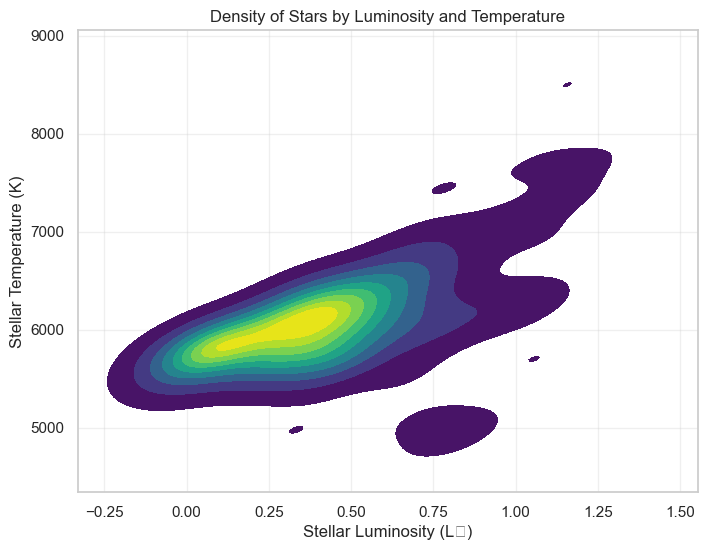

In [36]:
"""
Purpose:
This plot visualizes the density distribution of stars in terms of luminosity (brightness) and effective temperature.
It helps us understand where most stars fall on the luminosity-temperature plane
"""
plt.figure(figsize=(8,6))  

sns.kdeplot(
    x=df["stellar_lum"],        # Stellar luminosity in units of solar luminosity
    y=df["stellar_teff"],       # Stellar effective temperature in Kelvin
    fill=True,                  # Fill the density contours with color
    cmap="viridis",             # Color map for density visualization
    thresh=0.05                 # Minimum density threshold to avoid very sparse areas
)

# Add informative axis labels and title
plt.xlabel("Stellar Luminosity (L☉)")
plt.ylabel("Stellar Temperature (K)")
plt.title("Density of Stars by Luminosity and Temperature")

# Add grid lines
plt.grid(alpha=0.3)


"""
Insights:
- The heatmap shows where stars are most densely populated in luminosity-temperature space.
- Brighter regions indicate common types of stars (main-sequence stars), while sparse areas
  show rare types (giants, dwarfs, etc.)
- Understanding the distribution of stars helps contextualize habitable zones, 
  more stars in a certain luminosity range means more potential HZs at corresponding distances.
"""

# Display the plot
plt.show()